Problem statement
In this competition, you’re challenged to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t. You’ll have access to a dataset of 10,000 tweets that were hand classified. If this is your first time working on an NLP problem, we've created a quick tutorial to get you up and running.

Import libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

Load files

In [2]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read files

In [3]:
train = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")
submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Analyse target

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='target', ylabel='Density'>

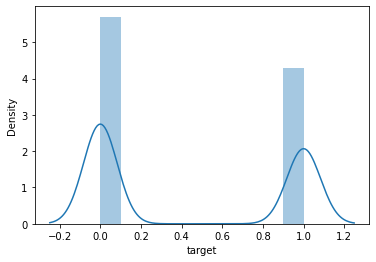

In [7]:
sns.distplot(train.target)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f5e3ff752d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f5e3ff75950>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f5e3ff69f10>],
 'medians': [<matplotlib.lines.Line2D at 0x7f5e3ff81050>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f5e3ff81390>],
 'means': []}

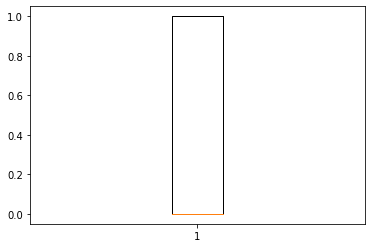

In [8]:
plt.boxplot(train.target)

Define target

In [9]:
target = train.target

Set dataframe up for NLTK

In [10]:
train.drop(['id', 'keyword', 'location'], axis=1, inplace=True)

feature = train.text.tolist()
label = train.target

Import libraries for NLTK

In [11]:
import random
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.classify import NaiveBayesClassifier as nbc
nltk.download('punkt')
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

NLTK preprocessing

In [12]:
stop_words = list(set(stopwords.words('english')))

documents = []
all_words = []

#j is adjective, r is adverb, and v is verb
allowed_word_types = ["J"]

for f in range(len(train)):
    documents.append(feature[f])
    feature[f] = feature[f].lower() 
    cleaned = re.sub(r'[^a-z\s]', '', feature[f])
    tokens = nltk.word_tokenize(cleaned)
    word_length = [i for i in tokens if 3 <=  len(i) <= 7]
    stopped = [w for w in word_length if not w in stop_words]
    all = nltk.pos_tag(stopped)
    
    for w in all:
        if w[1][0] in allowed_word_types:    
            all_words.append(w[0])

documents

['Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all',
 'Forest fire near La Ronge Sask. Canada',
 "All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected",
 '13,000 people receive #wildfires evacuation orders in California ',
 'Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school ',
 '#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires',
 '#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas',
 "I'm on top of the hill and I can see a fire in the woods...",
 "There's an emergency evacuation happening now in the building across the street",
 "I'm afraid that the tornado is coming to our area...",
 'Three people died from the heat wave so far',
 'Haha South Tampa is getting flooded hah- WAIT A SECOND I LIVE IN SOUTH TAMPA WHAT AM I GONNA DO WHAT AM I GONNA 

In [13]:
all_words = nltk.FreqDist(all_words)
all_words

FreqDist({'new': 226, 'nuclear': 102, 'full': 92, 'dead': 91, 'many': 84, 'good': 84, 'last': 83, 'best': 67, 'black': 66, 'hot': 65, ...})

In [14]:
word_features = list(all_words.keys())
word_features

['forgive',
 'forest',
 'shelter',
 'sent',
 'update',
 'due',
 'county',
 'heavy',
 'top',
 'afraid',
 'hah',
 'wait',
 'second',
 'live',
 'florida',
 'last',
 'side',
 'much',
 'new',
 'inec',
 'ablaze',
 'outside',
 'alive',
 'dead',
 'awesome',
 'cfc',
 'perfect',
 'weird',
 'better',
 'wear',
 'single',
 'next',
 'least',
 'black',
 'happy',
 'hard',
 'kiss',
 'los',
 'sunset',
 'mac',
 'secret',
 'navista',
 'ian',
 'huge',
 'cant',
 'slower',
 'usual',
 'great',
 'america',
 'teen',
 'double',
 'wished',
 'able',
 'median',
 'first',
 'eddy',
 'nha',
 'right',
 'fucking',
 'painful',
 'scuf',
 'free',
 'best',
 'ive',
 'minute',
 'daily',
 'many',
 'protect',
 'global',
 'scary',
 'full',
 'wrong',
 'dream',
 'die',
 'lose',
 'tried',
 'want',
 'oyster',
 'hybrid',
 'french',
 'strict',
 'common',
 'good',
 'bin',
 'laden',
 'ironic',
 'usama',
 'nicole',
 'little',
 'trauma',
 'omg',
 'close',
 'come',
 'serious',
 'crazy',
 'lucky',
 'medical',
 'dual',
 'nhs',
 'shit',
 'nig

Function to select features

In [15]:
def find_features(document):
    words = word_tokenize(document)
    features = {}
    for w in word_features:
        features[w] = (w in words)
    return features

Extract features

In [16]:
train.text = documents

featuresets = [(find_features(feature), label) for index, (feature, label) in train.iterrows()]
random.shuffle(featuresets) 

Split training set

In [17]:
train_len = int(len(train) * .8)

train_set = np.array(featuresets[: train_len])
test_set = np.array(featuresets[train_len :])

train_set[0]

array([{'forgive': False, 'forest': False, 'shelter': False, 'sent': True, 'update': False, 'due': False, 'county': False, 'heavy': False, 'top': False, 'afraid': False, 'hah': False, 'wait': False, 'second': False, 'live': False, 'florida': False, 'last': False, 'side': False, 'much': False, 'new': False, 'inec': False, 'ablaze': False, 'outside': False, 'alive': False, 'dead': False, 'awesome': False, 'cfc': False, 'perfect': False, 'weird': False, 'better': False, 'wear': False, 'single': False, 'next': False, 'least': False, 'black': False, 'happy': False, 'hard': False, 'kiss': False, 'los': False, 'sunset': False, 'mac': False, 'secret': False, 'navista': False, 'ian': False, 'huge': False, 'cant': False, 'slower': False, 'usual': False, 'great': False, 'america': False, 'teen': False, 'double': False, 'wished': False, 'able': False, 'median': False, 'first': False, 'eddy': False, 'nha': False, 'right': False, 'fucking': False, 'painful': False, 'scuf': False, 'free': False, 'bes

Define NLTK classifier

In [18]:
classifier = nbc.train(train_set)
print("Classifier accuracy percent: ", (nltk.classify.accuracy(classifier, test_set)) * 100)
classifier.show_most_informative_features(15)

Classifier accuracy percent:  65.72554169402494
Most Informative Features
                 suicide = True                1 : 0      =     26.0 : 1.0
                   fatal = True                1 : 0      =     16.6 : 1.0
                     due = True                1 : 0      =     16.5 : 1.0
                 suspect = True                1 : 0      =     14.7 : 1.0
                  atomic = True                1 : 0      =     11.0 : 1.0
                   flash = True                1 : 0      =     10.3 : 1.0
                  bigger = True                1 : 0      =      9.4 : 1.0
                    song = True                0 : 1      =      9.2 : 1.0
                    love = True                0 : 1      =      8.4 : 1.0
                   wrong = True                0 : 1      =      8.2 : 1.0
                    near = True                1 : 0      =      8.2 : 1.0
                 collide = True                0 : 1      =      7.7 : 1.0
                 blazing =